In [2]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian, median
import xarray as xr

import sys
sys.path.append('..')
from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

In [2]:
data_folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/Ximea_Calibration"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [3]:
image_size = 12
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
R, G, B, wavelength = S_F.getpixelefficiency()
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
camera_parameters["offset"] = np.full((image_size, image_size), np.median(offset))
camera_parameters["variance"] = np.full((image_size, image_size), np.median(variance))
camera_parameters["readnoise"] = np.full((image_size, image_size), np.median(readnoise))
camera_parameters["rqe"] = np.full((image_size, image_size), np.median(rqe))
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ['B', 'G', 'R']
camera_parameters["pixel_order_indices"] = [0, 1, 2]
camera_parameters["masks"] = masks

In [4]:
n_photon_space = np.arange(500, 5500, 500)
n_bootstrap = 1000
background_photons = 4
pixel_size = 69
NA = 1.49

In [5]:
import types
fitter = types.SimpleNamespace()
fitter.default_params = np.array(["xc", "yc", "A", "sigma", "b", "B", "G", "R"])
fitter.fit_function = I_AF.WLS_fit_colour
smoothing_function = types.SimpleNamespace()
smoothing_extent_median = np.arange(11)
smoothing_extent_uniform = np.arange(11)
smoothing_function.data_arg = "image"

In [6]:
dyes = ['ATTO 565']
fitter.dye_library = dyes

In [9]:
notch_filter = 'semrock-nf03-405-488-561-635e'
dichroic_mirror = 'semrock-di03-r405-488-561-635-t1-25x36'
nilered_filter = 'semrock-ff01-650-200-25'
shortpass_filter = 'semrock-bsp01-785r'
filters = [notch_filter, dichroic_mirror, shortpass_filter]

In [10]:
smoothing_functions = [sCMOS.bayer_bin_stack]

In [3]:
save_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20250328_TestingSmoothers'
if not os.path.isdir(save_folder):
    os.makedirs(save_folder)

In [12]:
smoothing_function.smoothing_function = sCMOS.bayer_bin_stack
extent = 2
smoothing_function.args = {"bin_width" : extent}
smoothing_function.extent = extent
for dye in dyes:
    print("Analysing dye {}".format(dye), end="\r",flush=True,)        
    MSF.test_single_fit_method(
                            dye,
                            filters,
                            wavelength,
                            camera_parameters,
                            fitter,
                            smoothing_function,
                            save_folder,
                            n_photon_space,
                            n_bootstrap=n_bootstrap,
                            background_photons=background_photons,
                            NA=NA,
                            pixel_size=pixel_size,
                            cpu_fraction=1,
                        )

In [ ]:
for i in smoothing_extent:
    for sf in smoothing_functions:
        smoothing_function.smoothing_function = sf
        if smoothing_function.smoothing_function.__name__ == 'gaussian_filter_stack':
            extent = smoothing_extent_gaussian[i]
            smoothing_function.args = {"sigma" : extent}
        elif smoothing_function.smoothing_function.__name__ == 'median_filter_stack':
            extent = smoothing_extent_median[i]
            smoothing_function.args = {"footprint" : np.ones([extent, extent])}
        elif smoothing_function.smoothing_function.__name__ == 'var_weighted_uniform_filter':
            extent = smoothing_extent_uniform[i]
            smoothing_function.args = {"variance_map" : camera_parameters["variance"],
                   "kernel_size": extent}
        smoothing_function.extent = extent
        for dye in dyes:
            print("Analysing dye {}".format(dye), end="\r",flush=True,)        
            MSF.test_single_fit_method(
                                    dye,
                                    filters,
                                    wavelength,
                                    camera_parameters,
                                    fitter,
                                    smoothing_function,
                                    save_folder,
                                    n_photon_space,
                                    n_bootstrap=n_bootstrap,
                                    background_photons=background_photons,
                                    NA=NA,
                                    pixel_size=pixel_size,
                                    cpu_fraction=1,
                                )

In [31]:
n_photon_space = np.arange(500, 5100, 100)
smoothing_extent_gaussian = np.linspace(0, 3, 31)
smoothing_functions = [sCMOS.gaussian_filter_stack]

In [12]:
for i, val in enumerate(smoothing_extent_gaussian):
    for sf in smoothing_functions:
        smoothing_function.smoothing_function = sf
        if smoothing_function.smoothing_function.__name__ == 'gaussian_filter_stack':
            extent = smoothing_extent_gaussian[i]
            smoothing_function.args = {"sigma" : extent}
        elif smoothing_function.smoothing_function.__name__ == 'median_filter_stack':
            extent = smoothing_extent_median[i]
            smoothing_function.args = {"footprint" : np.ones([extent, extent])}
        elif smoothing_function.smoothing_function.__name__ == 'var_weighted_uniform_filter':
            extent = smoothing_extent_uniform[i]
            smoothing_function.args = {"variance_map" : camera_parameters["variance"],
                   "kernel_size": extent}
        smoothing_function.extent = extent
        for dye in dyes:
            print("Analysing dye {}".format(dye), end="\r",flush=True,)        
            MSF.test_single_fit_method(
                                    dye,
                                    filters,
                                    wavelength,
                                    camera_parameters,
                                    fitter,
                                    smoothing_function,
                                    save_folder,
                                    n_photon_space,
                                    n_bootstrap=n_bootstrap,
                                    background_photons=background_photons,
                                    NA=NA,
                                    pixel_size=pixel_size,
                                    cpu_fraction=1,
                                )

In [4]:
import polars as pl
folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20250328_TestingSmoothers/'
files = os.listdir(folder)

In [5]:
def make_smoothing_matrix(folder, smoother_type):
    smoothing_files = np.sort([x for x in files if smoother_type in x])
    smoothing_mean_files = np.sort([x for x in smoothing_files if 'mean' in x])
    smoothing_std_files = np.sort([x for x in smoothing_files if 'std' in x])
    file_dims = pl.read_csv(os.path.join(folder, smoothing_files[0]))
    xarray_shape = file_dims.to_numpy()[:, 1:].shape + (len(smoothing_mean_files), )
    dims = ['n_photons', 'parameter', 'smoothing_extent']
    coords = {}
    coords['n_photons'] =  file_dims['n_photons'].to_numpy()
    coords['parameter'] =  file_dims.columns[1:]
    smoothing_extent = np.array([float(x.split('smoothingextent_')[1].split('_')[0].replace('p', '.')) for x in smoothing_mean_files])
    sort_indices = np.argsort(smoothing_extent)
    coords['smoothing_extent'] = smoothing_extent[sort_indices]
    smoothing_means = xr.DataArray(data=np.zeros(xarray_shape), dims=dims, coords=coords)
    smoothing_stds = xr.DataArray(data=np.zeros(xarray_shape), dims=dims, coords=coords)
    for i, file in enumerate(smoothing_mean_files[sort_indices]):
        data = pl.read_csv(os.path.join(folder, file))
        smoothing_means.values[:, :, i] = data.to_numpy()[:, 1:]
    for i, file in enumerate(smoothing_std_files[sort_indices]):
        data = pl.read_csv(os.path.join(folder, file))
        smoothing_stds.values[:, :, i] = data.to_numpy()[:, 1:]
    return smoothing_means, smoothing_stds

In [6]:
gaussian_means, gaussian_stds = make_smoothing_matrix(folder, 'gaussian')
median_means, median_stds = make_smoothing_matrix(folder, 'median')
uniform_means, uniform_stds = make_smoothing_matrix(folder, 'uniform')

In [7]:
bayer_means, bayer_stds = make_smoothing_matrix(folder, 'bayer')

In [8]:
gaussian_means.shape

(10, 5, 31)

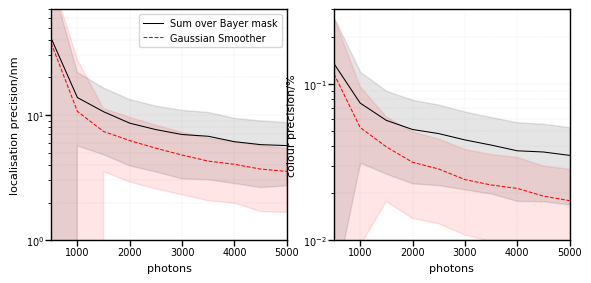

In [24]:
fig, axs = plotter.two_column_plot(widthratio=[1,1], ncolumns=2)

axs[0] = plotter.line_error_plot(axs=axs[0], x=bayer_means.n_photons.values, y=bayer_means[:, 0, 0].values, yerror=bayer_stds[:, 0, 0].values, 
                                 alpha=0.1, yaxislabel='localisation precision/nm', xaxislabel='photons', label='Sum over Bayer mask')

axs[0] = plotter.line_error_plot(axs=axs[0], x=gaussian_means.n_photons.values, y=gaussian_means[:, 0, 15].values, yerror=gaussian_stds[:, 0, 15].values, 
                                 alpha=0.1, yaxislabel='localisation precision/nm', xaxislabel='photons', label='Gaussian Smoother',
                                color='red', ls='--')

axs[0].set_ylim([1, 70])
axs[0].set_yscale('log')
axs[0].legend(loc='best')

axs[1] = plotter.line_error_plot(axs=axs[1], x=bayer_means.n_photons.values, y=bayer_means[:, -1, 0].values, yerror=bayer_stds[:, -1, 0].values, 
                                 alpha=0.1, yaxislabel=r'colour precision/%', xaxislabel='photons')

axs[1] = plotter.line_error_plot(axs=axs[1], x=gaussian_means.n_photons.values, y=gaussian_means[:, -1, 15].values, yerror=gaussian_stds[:, -1, 15].values, 
                                 alpha=0.1, yaxislabel=r'colour precision/%', xaxislabel='photons',
                                color='red', ls='--')

axs[1].set_ylim([1e-2, 0.3])
axs[1].set_yscale('log')
folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250522/fig/multicolour/smoothing_parameters/'
plt.savefig(os.path.join(folder, 'bayer_smoothing_overlaid_Gaussian.svg'), dpi=600, format='svg')

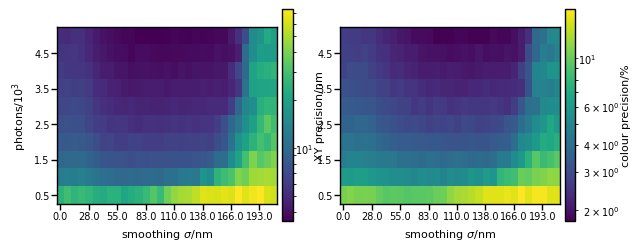

In [13]:
fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])

Z = gaussian_means[:, 0, :]

import matplotlib
cbarlabel = 'XY precision/nm'
im = axs[0].imshow(Z, cmap='viridis', origin='lower', aspect=2.5, norm=matplotlib.colors.LogNorm(vmin=np.nanmin(Z), vmax=np.max(Z)))
cbar = plt.colorbar(im, fraction=0.045, pad=0.02, ax=axs[0], location="right")
cbar.set_label(cbarlabel, rotation=90, labelpad=1, fontsize=8)
cbar.ax.tick_params(labelsize=7, pad=0.1, width=0.5, length=2)
axs[0].set_xticks(np.arange(0, 31, 4))
real_x = gaussian_means['smoothing_extent'].values[np.arange(0, 31, 4)][:len(np.arange(0, 31, 4))]
axs[0].set_xticklabels(np.around(real_x*69, 0))
axs[0].set_xlabel(r'smoothing $\sigma$/nm', fontsize=8)

axs[0].set_yticks(np.arange(0, 10, 2))
real_y = gaussian_means['n_photons'].values[np.arange(0, 10, 2)][:len(np.arange(0, 10, 2))]
axs[0].set_yticklabels(np.around(real_y/1000, 1))

axs[0].set_ylabel(r'photons/10$^3$', fontsize=8)

Z = gaussian_means[:, -1, :]*100

cbarlabel = 'colour precision/%'
im = axs[1].imshow(Z, cmap='viridis', origin='lower', norm=matplotlib.colors.LogNorm(vmin=np.nanmin(Z), vmax=np.max(Z)), aspect=2.5)
cbar = plt.colorbar(im, fraction=0.045, pad=0.02, ax=axs[1], location="right")
cbar.set_label(cbarlabel, rotation=90, labelpad=1, fontsize=8)
cbar.ax.tick_params(labelsize=7, pad=0.1, width=0.5, length=2)
axs[1].set_xlabel(r'smoothing $\sigma$/nm', fontsize=8)
axs[1].set_xticks(np.arange(0, 31, 4))
real_x = gaussian_means['smoothing_extent'].values[np.arange(0, 31, 4)][:len(np.arange(0, 31, 4))]
axs[1].set_xticklabels(np.around(real_x*69, 0))
axs[1].set_yticks(np.arange(0, 10, 2))
real_y = gaussian_means['n_photons'].values[np.arange(0, 10, 2)][:len(np.arange(0, 10, 2))]
axs[1].set_yticklabels(np.around(real_y/1000, 1))



folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250522/fig/multicolour/smoothing_parameters/'
plt.savefig(os.path.join(folder, 'gaussian_smoothing.svg'), dpi=600, format='svg')

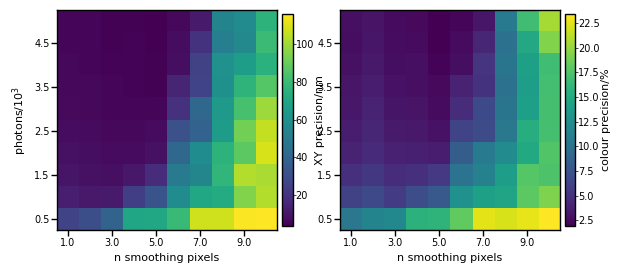

In [22]:
fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])

Z = median_means[:, 0, :]

cbarlabel = 'XY precision/nm'
im = axs[0].imshow(Z, cmap='viridis', origin='lower', vmin=np.nanmin(Z), vmax=np.max(Z))
cbar = plt.colorbar(im, fraction=0.045, pad=0.02, ax=axs[0], location="right")
cbar.set_label(cbarlabel, rotation=90, labelpad=1, fontsize=8)
cbar.ax.tick_params(labelsize=7, pad=0.1, width=0.5, length=2)
axs[0].set_xticks(np.arange(0, 10, 2))
real_x = median_means['smoothing_extent'].values[np.arange(0, 10, 2)][:len(np.arange(0, 10, 2))]
axs[0].set_xticklabels(np.around(real_x, 0))
axs[0].set_xlabel(r'n smoothing pixels', fontsize=8)

axs[0].set_yticks(np.arange(0, 10, 2))
real_y = median_means['n_photons'].values[np.arange(0, 10, 2)][:len(np.arange(0, 10, 2))]
axs[0].set_yticklabels(np.around(real_y/1000, 1))

axs[0].set_ylabel(r'photons/10$^3$', fontsize=8)

Z = median_means[:, -1, :]*100

cbarlabel = 'colour precision/%'
im = axs[1].imshow(Z, cmap='viridis', origin='lower', vmin=np.nanmin(Z), vmax=np.max(Z))
cbar = plt.colorbar(im, fraction=0.045, pad=0.02, ax=axs[1], location="right")
cbar.set_label(cbarlabel, rotation=90, labelpad=1, fontsize=8)
cbar.ax.tick_params(labelsize=7, pad=0.1, width=0.5, length=2)
axs[1].set_xlabel(r'n smoothing pixels', fontsize=8)
axs[1].set_xticks(np.arange(0, 10, 2))
real_x = median_means['smoothing_extent'].values[np.arange(0, 10, 2)][:len(np.arange(0, 10, 2))]
axs[1].set_xticklabels(np.around(real_x, 0))
axs[1].set_yticks(np.arange(0, 10, 2))
real_y = median_means['n_photons'].values[np.arange(0, 10, 2)][:len(np.arange(0, 10, 2))]
axs[1].set_yticklabels(np.around(real_y/1000, 1))


folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250424/fig/multicolour/smoothing_parameters/'
plt.savefig(os.path.join(folder, 'median_smoothing.svg'), dpi=600, format='svg')

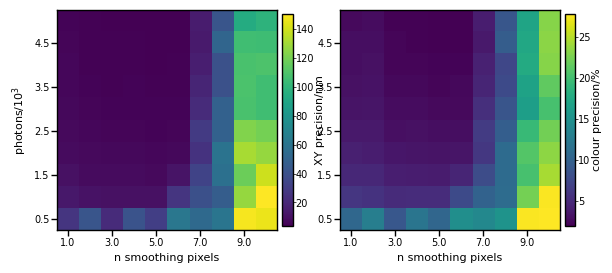

In [23]:
fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])

Z = uniform_means[:, 0, :]

cbarlabel = 'XY precision/nm'
im = axs[0].imshow(Z, cmap='viridis', origin='lower', vmin=np.nanmin(Z), vmax=np.max(Z))
cbar = plt.colorbar(im, fraction=0.045, pad=0.02, ax=axs[0], location="right")
cbar.set_label(cbarlabel, rotation=90, labelpad=1, fontsize=8)
cbar.ax.tick_params(labelsize=7, pad=0.1, width=0.5, length=2)
axs[0].set_xticks(np.arange(0, 10, 2))
real_x = uniform_means['smoothing_extent'].values[np.arange(0, 10, 2)][:len(np.arange(0, 10, 2))]
axs[0].set_xticklabels(np.around(real_x, 0))
axs[0].set_xlabel(r'n smoothing pixels', fontsize=8)

axs[0].set_yticks(np.arange(0, 10, 2))
real_y = uniform_means['n_photons'].values[np.arange(0, 10, 2)][:len(np.arange(0, 10, 2))]
axs[0].set_yticklabels(np.around(real_y/1000, 1))

axs[0].set_ylabel(r'photons/10$^3$', fontsize=8)

Z = uniform_means[:, -1, :]*100

cbarlabel = 'colour precision/%'
im = axs[1].imshow(Z, cmap='viridis', origin='lower', vmin=np.nanmin(Z), vmax=np.max(Z))
cbar = plt.colorbar(im, fraction=0.045, pad=0.02, ax=axs[1], location="right")
cbar.set_label(cbarlabel, rotation=90, labelpad=1, fontsize=8)
cbar.ax.tick_params(labelsize=7, pad=0.1, width=0.5, length=2)
axs[1].set_xlabel(r'n smoothing pixels', fontsize=8)
axs[1].set_xticks(np.arange(0, 10, 2))
real_x = uniform_means['smoothing_extent'].values[np.arange(0, 10, 2)][:len(np.arange(0, 10, 2))]
axs[1].set_xticklabels(np.around(real_x, 0))
axs[1].set_yticks(np.arange(0, 10, 2))
real_y = uniform_means['n_photons'].values[np.arange(0, 10, 2)][:len(np.arange(0, 10, 2))]
axs[1].set_yticklabels(np.around(real_y/1000, 1))


folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250424/fig/multicolour/smoothing_parameters/'
plt.savefig(os.path.join(folder, 'uniform_smoothing.svg'), dpi=600, format='svg')